In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error

import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('imports ok')

Importing plotly failed. Interactive plots will not work.


imports ok


In [2]:
PATH = 'slooze_challenge./'

purchases = pd.read_csv(PATH + 'PurchasesFINAL12312016.csv')
sales_jan_feb = pd.read_csv(PATH + 'SalesFINAL12312016.csv')
abc  = pd.read_csv(PATH + 'abc_classified_products.csv')

purchases['PODate']        = pd.to_datetime(purchases['PODate'])
purchases['ReceivingDate'] = pd.to_datetime(purchases['ReceivingDate'])
sales_jan_feb['SalesDate'] = pd.to_datetime(sales_jan_feb['SalesDate'], format='mixed')

print('purchases date range:', purchases['PODate'].min().date(), '-->', purchases['PODate'].max().date())
print('sales date range:    ', sales_jan_feb['SalesDate'].min().date(), '-->', sales_jan_feb['SalesDate'].max().date())
print('(sales file capped at Excel row limit — Jan/Feb only)')

purchases date range: 2015-12-20 --> 2016-12-23
sales date range:     2016-01-01 --> 2016-02-29
(sales file capped at Excel row limit — Jan/Feb only)


Daily demand series: 366 days, 33,584,377 total units


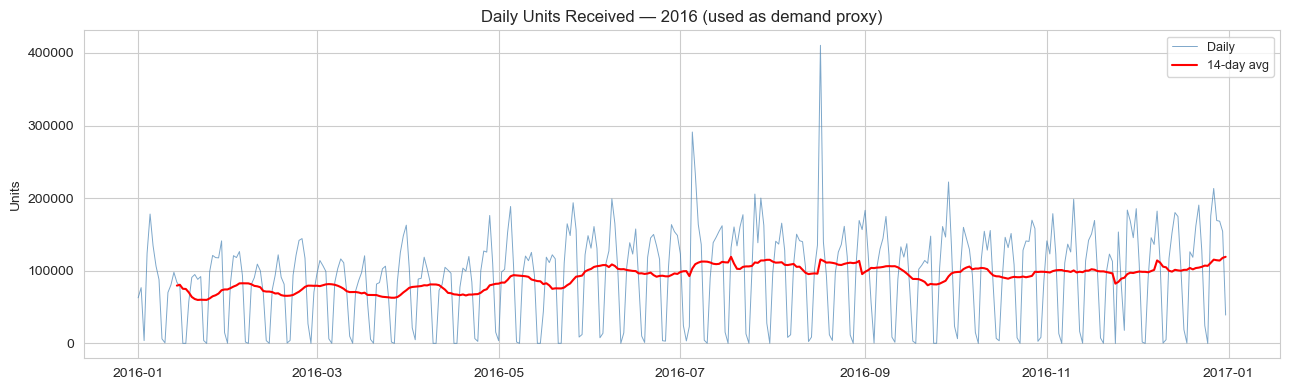

In [4]:
purch_2016 = purchases[(purchases['ReceivingDate'] >= '2016-01-01') &
                        (purchases['ReceivingDate'] <= '2016-12-31')].copy()

daily = (
    purch_2016.groupby('ReceivingDate')
    .agg(units=('Quantity','sum'), spend=('Dollars','sum'))
    .reset_index()
    .rename(columns={'ReceivingDate':'ds', 'units':'y'})
    .sort_values('ds')
)

full_range = pd.date_range('2016-01-01','2016-12-31')
daily = daily.set_index('ds').reindex(full_range, fill_value=0).reset_index()
daily.columns = ['ds','y','spend']

print(f'Daily demand series: {len(daily)} days, {daily["y"].sum():,.0f} total units')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily['ds'], daily['y'], color='steelblue', linewidth=0.7, alpha=0.7, label='Daily')
ax.plot(daily['ds'], daily['y'].rolling(14).mean(), color='red', linewidth=1.5, label='14-day avg')
ax.set_title('Daily Units Received — 2016 (used as demand proxy)')
ax.set_ylabel('Units')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot_daily_demand_raw.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
train = daily[daily['ds'] < '2016-11-01'][['ds','y']]
test  = daily[daily['ds'] >= '2016-11-01'][['ds','y']]

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)
m.fit(train)

future = m.make_future_dataframe(periods=len(test) + 90)
forecast = m.predict(future)

test_fc = forecast[forecast['ds'].isin(test['ds'])].copy()
mae = mean_absolute_error(test['y'].values, test_fc['yhat'].clip(0).values)
print(f'Test MAE: {mae:.1f} units/day')

21:52:55 - cmdstanpy - INFO - Chain [1] start processing
21:52:56 - cmdstanpy - INFO - Chain [1] done processing


Test MAE: 31009.2 units/day


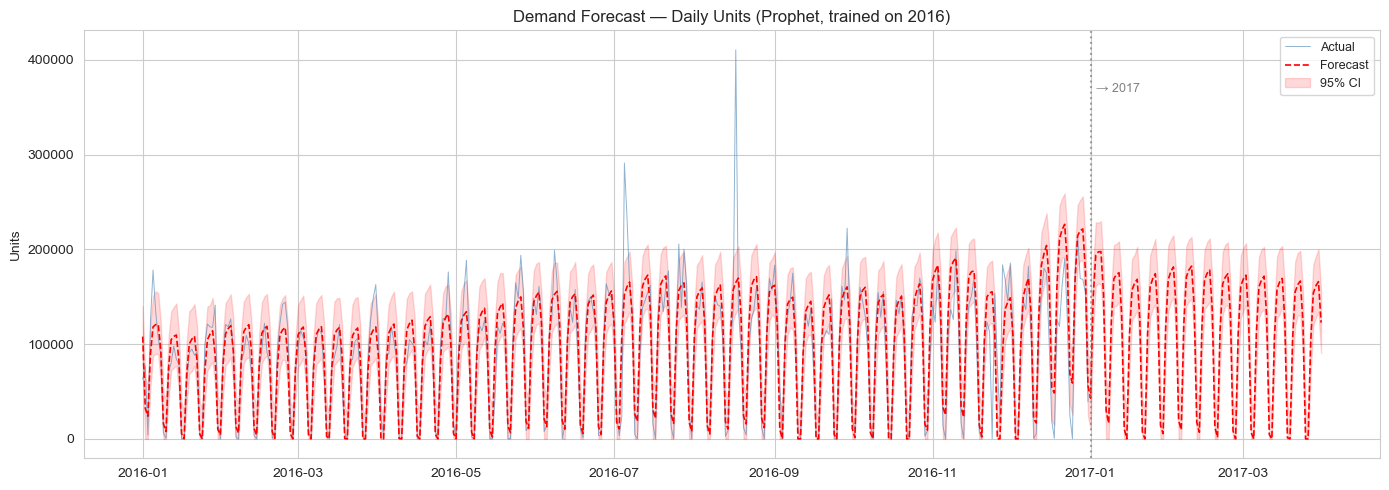

Q1 2017 forecast: 10,081,627 units total
Daily avg Q1:     112,018 units/day


In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily['ds'], daily['y'], color='steelblue', linewidth=0.7, alpha=0.6, label='Actual')
ax.plot(forecast['ds'], forecast['yhat'].clip(0), color='red', linewidth=1.2,
        linestyle='--', label='Forecast')
ax.fill_between(forecast['ds'],
                forecast['yhat_lower'].clip(0),
                forecast['yhat_upper'].clip(0),
                alpha=0.15, color='red', label='95% CI')

ax.axvline(pd.Timestamp('2017-01-01'), color='grey', linestyle=':', alpha=0.7)
ax.text(pd.Timestamp('2017-01-03'), ax.get_ylim()[1]*0.85, '→ 2017', fontsize=9, color='grey')
ax.set_title('Demand Forecast — Daily Units (Prophet, trained on 2016)')
ax.set_ylabel('Units')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

q1 = forecast[(forecast['ds'] >= '2017-01-01') & (forecast['ds'] <= '2017-03-31')]
print(f'Q1 2017 forecast: {q1["yhat"].clip(0).sum():,.0f} units total')
print(f'Daily avg Q1:     {q1["yhat"].clip(0).mean():,.0f} units/day')

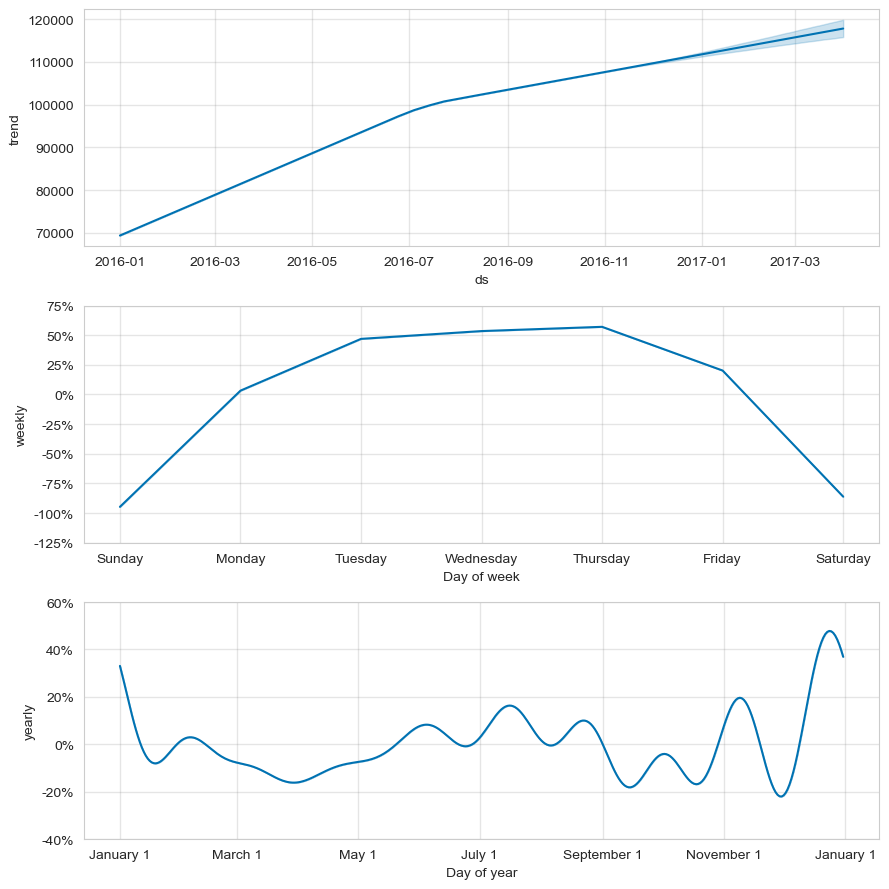

In [8]:
fig = m.plot_components(forecast)
plt.savefig('plot_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

Holt-Winters MAE (monthly): 335,364 units/month


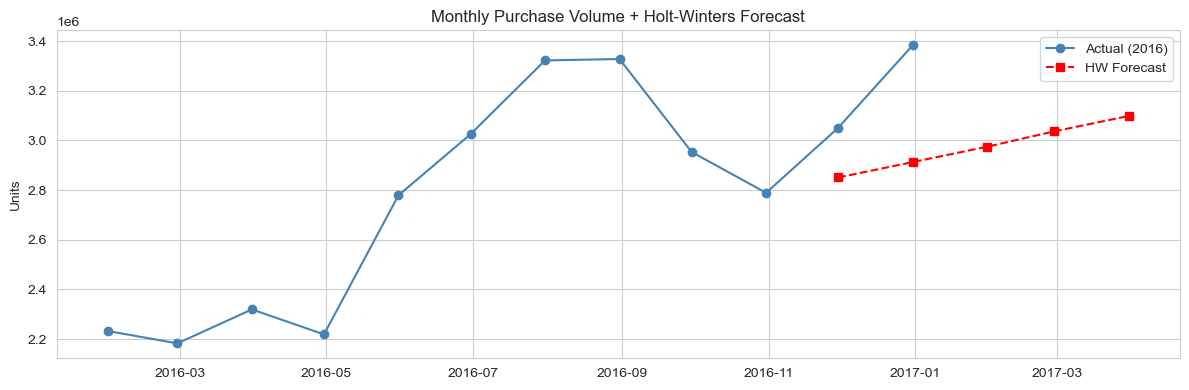


Q1 2017 monthly forecasts (Holt-Winters):
  Jan 2017: 2,974,857 units
  Feb 2017: 3,036,868 units
  Mar 2017: 3,098,879 units


In [10]:
monthly = (
    daily.set_index('ds').resample('ME')
    .agg(units=('y','sum'), spend=('spend','sum'))
    .reset_index()
)

train_m = monthly.iloc[:-2]
test_m  = monthly.iloc[-2:]

hw = ExponentialSmoothing(
    train_m['units'],
    trend='add',
    seasonal=None,
    initialization_method='estimated'
).fit()

hw_fc = hw.forecast(5)
hw_fc.index = pd.date_range(start=test_m['ds'].iloc[0], periods=5, freq='ME')

mae_hw = mean_absolute_error(test_m['units'].values, hw_fc.iloc[:2].clip(0).values)
print(f'Holt-Winters MAE (monthly): {mae_hw:,.0f} units/month')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['ds'], monthly['units'], marker='o', color='steelblue', label='Actual (2016)')
ax.plot(hw_fc.index, hw_fc.clip(0), marker='s', linestyle='--', color='red', label='HW Forecast')
ax.set_title('Monthly Purchase Volume + Holt-Winters Forecast')
ax.set_ylabel('Units')
ax.legend()
plt.tight_layout()
plt.savefig('plot_hw_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nQ1 2017 monthly forecasts (Holt-Winters):')
for date, units in hw_fc.iloc[2:].items():
    print(f'  {date.strftime("%b %Y")}: {max(0, int(units)):,} units')

21:53:31 - cmdstanpy - INFO - Chain [1] start processing
21:53:31 - cmdstanpy - INFO - Chain [1] done processing
21:53:32 - cmdstanpy - INFO - Chain [1] start processing
21:53:32 - cmdstanpy - INFO - Chain [1] done processing
21:53:32 - cmdstanpy - INFO - Chain [1] start processing
21:53:32 - cmdstanpy - INFO - Chain [1] done processing
21:53:33 - cmdstanpy - INFO - Chain [1] start processing
21:53:33 - cmdstanpy - INFO - Chain [1] done processing
21:53:34 - cmdstanpy - INFO - Chain [1] start processing
21:53:34 - cmdstanpy - INFO - Chain [1] done processing


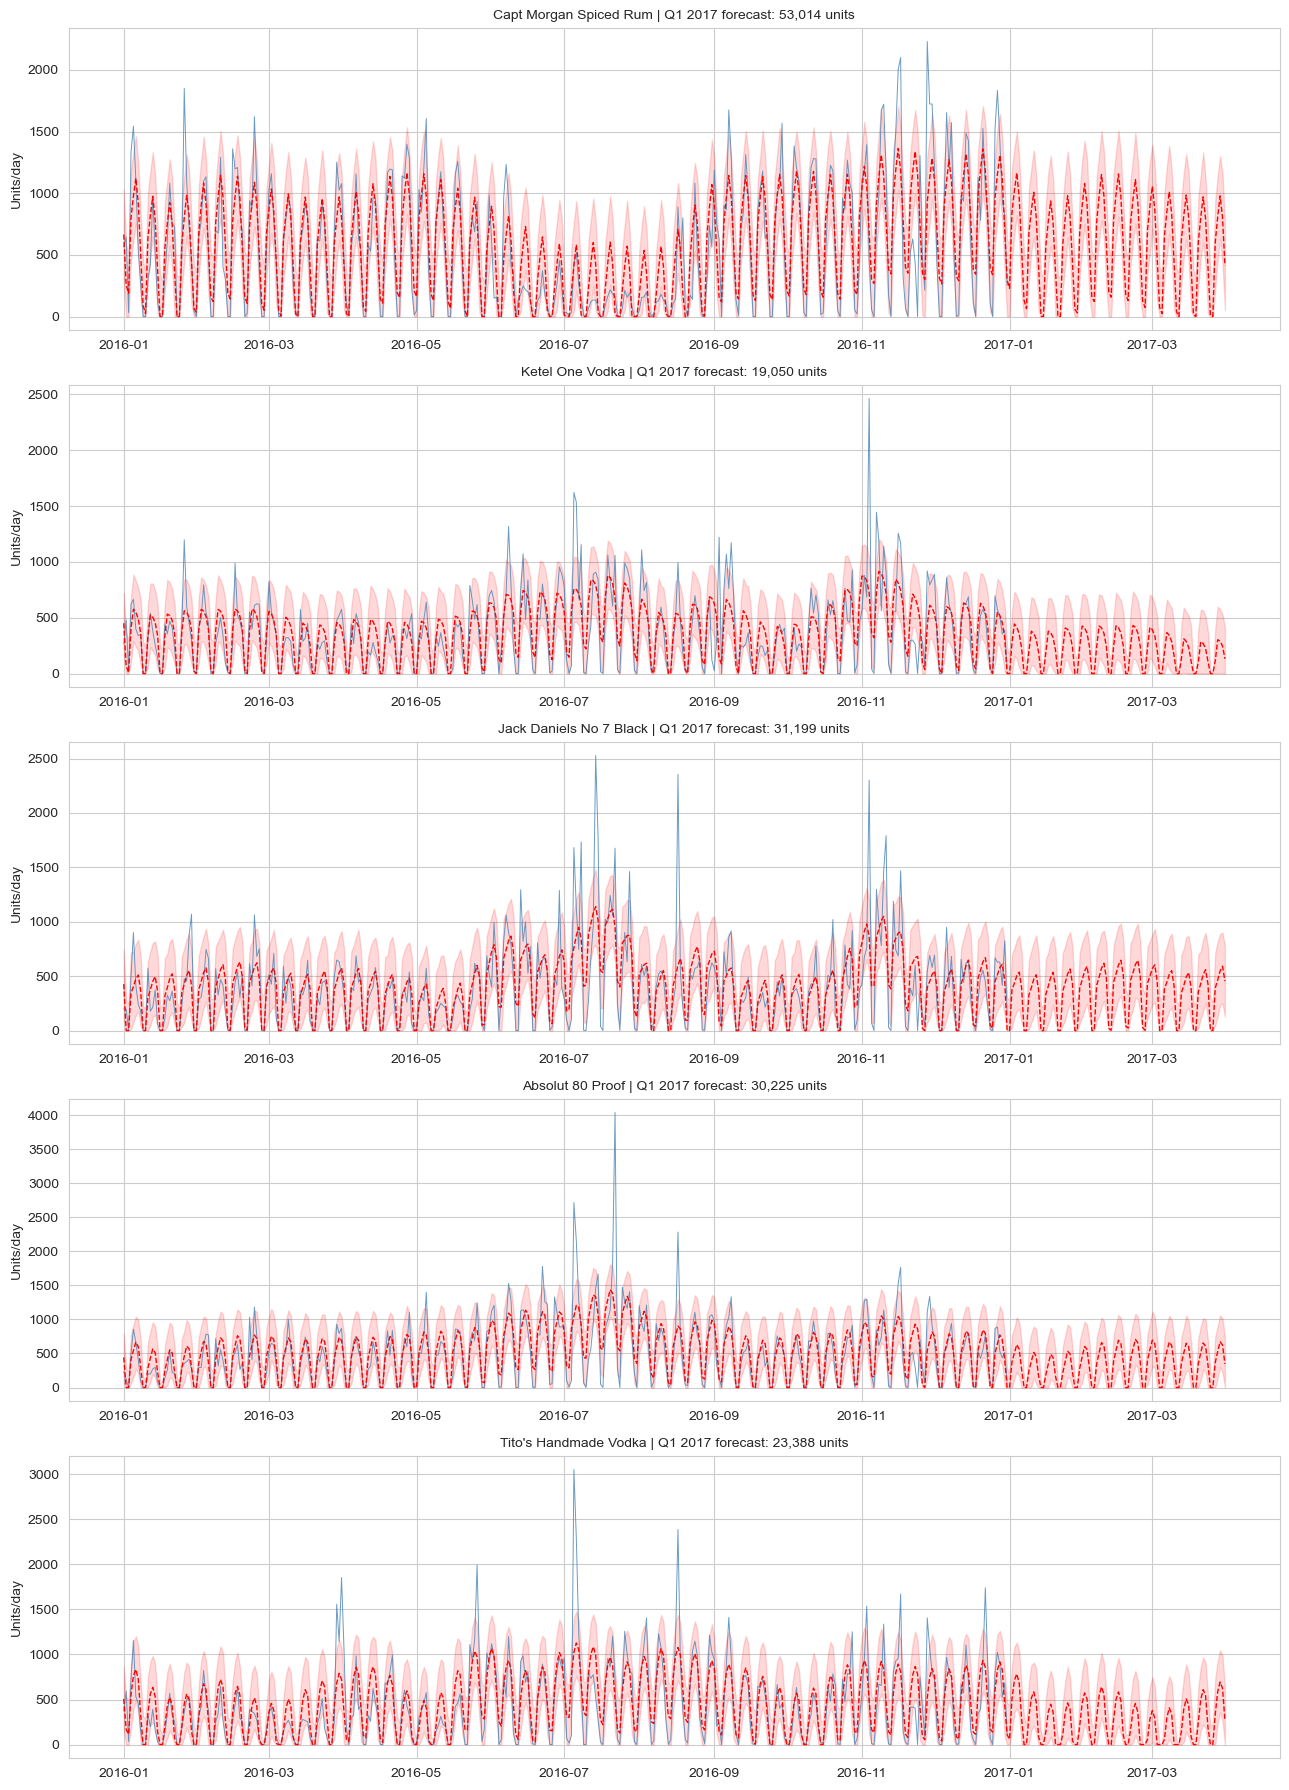

Q1 2017 product forecasts:
 Brand             Description  Q1_2017_forecast
  4261  Capt Morgan Spiced Rum             53014
  3545         Ketel One Vodka             19050
  1233 Jack Daniels No 7 Black             31199
  8068        Absolut 80 Proof             30225
  3405   Tito's Handmade Vodka             23388


In [11]:
a_items = abc[abc['ABC'] == 'A'].nlargest(5, 'total_revenue')

fig, axes = plt.subplots(5, 1, figsize=(13, 18))
product_forecasts = []

for i, (_, row) in enumerate(a_items.iterrows()):
    brand_id   = row['Brand']
    brand_name = str(row['Description'])[:40]

    prod_daily = (
        purch_2016[purch_2016['Brand'] == brand_id]
        .groupby('ReceivingDate')['Quantity'].sum()
        .reindex(pd.date_range('2016-01-01','2016-12-31'), fill_value=0)
        .reset_index()
    )
    prod_daily.columns = ['ds','y']

    if prod_daily['y'].sum() == 0:
        axes[i].set_title(f'{brand_name} — no purchase data')
        continue

    try:
        model = Prophet(
            weekly_seasonality=True,
            yearly_seasonality=True,
            daily_seasonality=False,
            changepoint_prior_scale=0.1
        )
        model.fit(prod_daily)
        fut = model.make_future_dataframe(periods=90)
        fc  = model.predict(fut)

        q1_units = fc[(fc['ds'] >= '2017-01-01') & (fc['ds'] <= '2017-03-31')]['yhat'].clip(0).sum()
        product_forecasts.append({'Brand': brand_id, 'Description': brand_name,
                                   'Q1_2017_forecast': round(q1_units)})

        ax = axes[i]
        ax.plot(prod_daily['ds'], prod_daily['y'], color='steelblue', linewidth=0.7, alpha=0.8)
        ax.plot(fc['ds'], fc['yhat'].clip(0), color='red', linewidth=1, linestyle='--')
        ax.fill_between(fc['ds'], fc['yhat_lower'].clip(0), fc['yhat_upper'].clip(0),
                        alpha=0.15, color='red')
        ax.set_title(f'{brand_name} | Q1 2017 forecast: {q1_units:,.0f} units', fontsize=10)
        ax.set_ylabel('Units/day')
    except Exception as e:
        axes[i].set_title(f'{brand_name} — failed: {e}')

plt.tight_layout()
plt.savefig('plot_product_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

if product_forecasts:
    print('Q1 2017 product forecasts:')
    print(pd.DataFrame(product_forecasts).to_string(index=False))

In [13]:
daily['rolling30'] = daily['y'].rolling(30).mean().shift(1)
test_base = daily[daily['ds'] >= '2016-11-01'].dropna(subset=['rolling30'])
mae_roll = mean_absolute_error(test_base['y'].values, test_base['rolling30'].values)

print('Model comparison (test: Nov-Dec 2016):')
print(f'  30-day rolling average: MAE = {mae_roll:.0f} units/day')
print(f'  Prophet:                MAE = {mae:.0f} units/day')
print(f'  Improvement over baseline: {(mae_roll - mae)/mae_roll*100:.1f}%')

Model comparison (test: Nov-Dec 2016):
  30-day rolling average: MAE = 58014 units/day
  Prophet:                MAE = 31009 units/day
  Improvement over baseline: 46.5%
